<a href="https://colab.research.google.com/github/Kachukwu-Goo/Internboot_Projects/blob/main/Project_3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Linear Regression for Sales Prediction**
A simple regression model to predict future sales based on time and promotions

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [1]:
#load data
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv
Saving transactions.csv to transactions.csv
Saving holidays_events.csv to holidays_events.csv
Saving oil.csv to oil.csv
Saving sample_submission.csv to sample_submission.csv
Saving stores.csv to stores.csv
Saving test.csv to test.csv


In [4]:
# ---- Aggregate to daily total sales (across all stores/items) ----
daily = train.groupby("date").agg(
    sales=("sales", "sum"),
    onpromotion=("onpromotion", "sum")
).reset_index()

In [6]:
train = pd.read_csv("train.csv", parse_dates=["date"])
holidays = pd.read_csv("holidays_events.csv", parse_dates=["date"])

print(train.shape)
print(holidays.shape)

(3000888, 6)
(350, 6)


In [7]:
# ---- Holiday flag: national holidays that weren't transferred to another date ----
national_holidays = holidays[
    (holidays["locale"] == "National") & (holidays["transferred"] == False)
]["date"].unique()
daily["is_holiday"] = daily["date"].isin(national_holidays).astype(int)

In [9]:
# ---- Date-based features ----
daily["month"] = daily["date"].dt.month
daily["dayofweek"] = daily["date"].dt.dayofweek        # 0=Mon ... 6=Sun
daily["is_weekend"] = daily["dayofweek"].isin([5, 6]).astype(int)
daily["time_idx"] = (daily["date"] - daily["date"].min()).dt.days   # trend feature

In [10]:
# ---- Train/Test split (time-based — last 90 days as test, NOT random!) ----
test_days = 90
train_df = daily.iloc[:-test_days].copy()
test_df = daily.iloc[-test_days:].copy()

features = ["time_idx", "month", "dayofweek", "is_weekend", "is_holiday", "onpromotion"]
target = "sales"

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

print("Train period:", train_df["date"].min().date(), "to", train_df["date"].max().date())
print("Test period :", test_df["date"].min().date(), "to", test_df["date"].max().date())

Train period: 2013-01-01 to 2017-05-17
Test period : 2017-05-18 to 2017-08-15


In [11]:
# ---- Fit Linear Regression ----
model = LinearRegression()
model.fit(X_train, y_train)

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)


In [12]:
# ---- Evaluate ----
def report(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{label}: MAE={mae:,.0f}  RMSE={rmse:,.0f}  R2={r2:.3f}")

report(y_train, pred_train, "Train")
report(y_test, pred_test, "Test ")

print("\nFeature coefficients (how much each feature moves sales):")
for f, c in zip(features, model.coef_):
    print(f"  {f:>12}: {c:,.2f}")
print(f"  {'intercept':>12}: {model.intercept_:,.2f}")

Train: MAE=90,586  RMSE=120,689  R2=0.729
Test : MAE=105,854  RMSE=124,265  R2=0.427

Feature coefficients (how much each feature moves sales):
      time_idx: 310.46
         month: 7,561.27
     dayofweek: -13,392.65
    is_weekend: 274,339.94
    is_holiday: 77,258.55
   onpromotion: 4.62
     intercept: 266,638.73


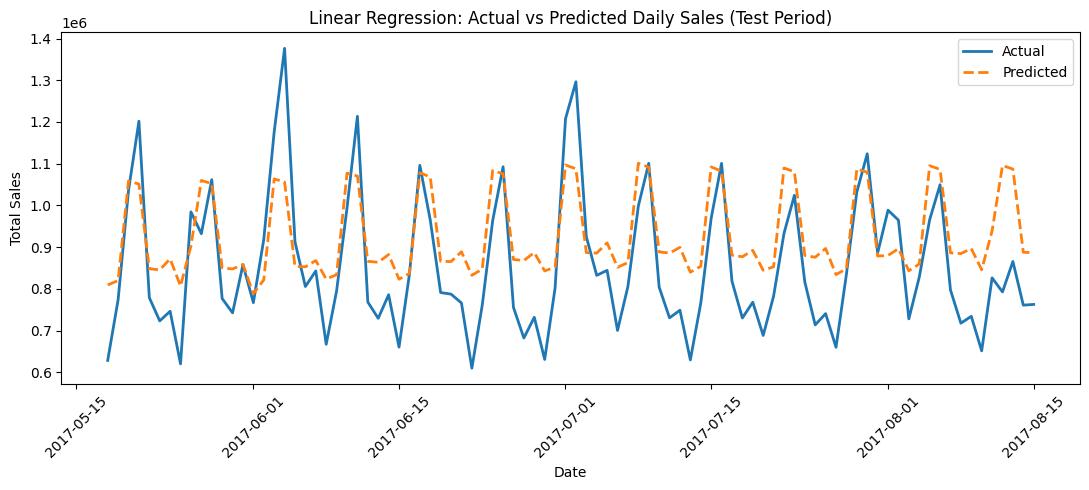

In [14]:
# ---- Plot actual vs predicted ----
plt.figure(figsize=(11, 5))
plt.plot(test_df["date"], y_test, label="Actual", linewidth=2)
plt.plot(test_df["date"], pred_test, label="Predicted", linewidth=2, linestyle="--")
plt.title("Linear Regression: Actual vs Predicted Daily Sales (Test Period)")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This is a simple model to predict daily sales using the date, whether it's a weekend or holiday, and how many items were on promotion.
it explains past sale with a 73% accuracy but got weaker on new, unseen days (43%). It correctly learned that weekends and holidays boost sales which makes sense, that's when people shop more. But it missed the sudden big spikes in sales, since a straight-line model just isn't flexible enough to catch those.